In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/dataset.csv')
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [ ]:
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


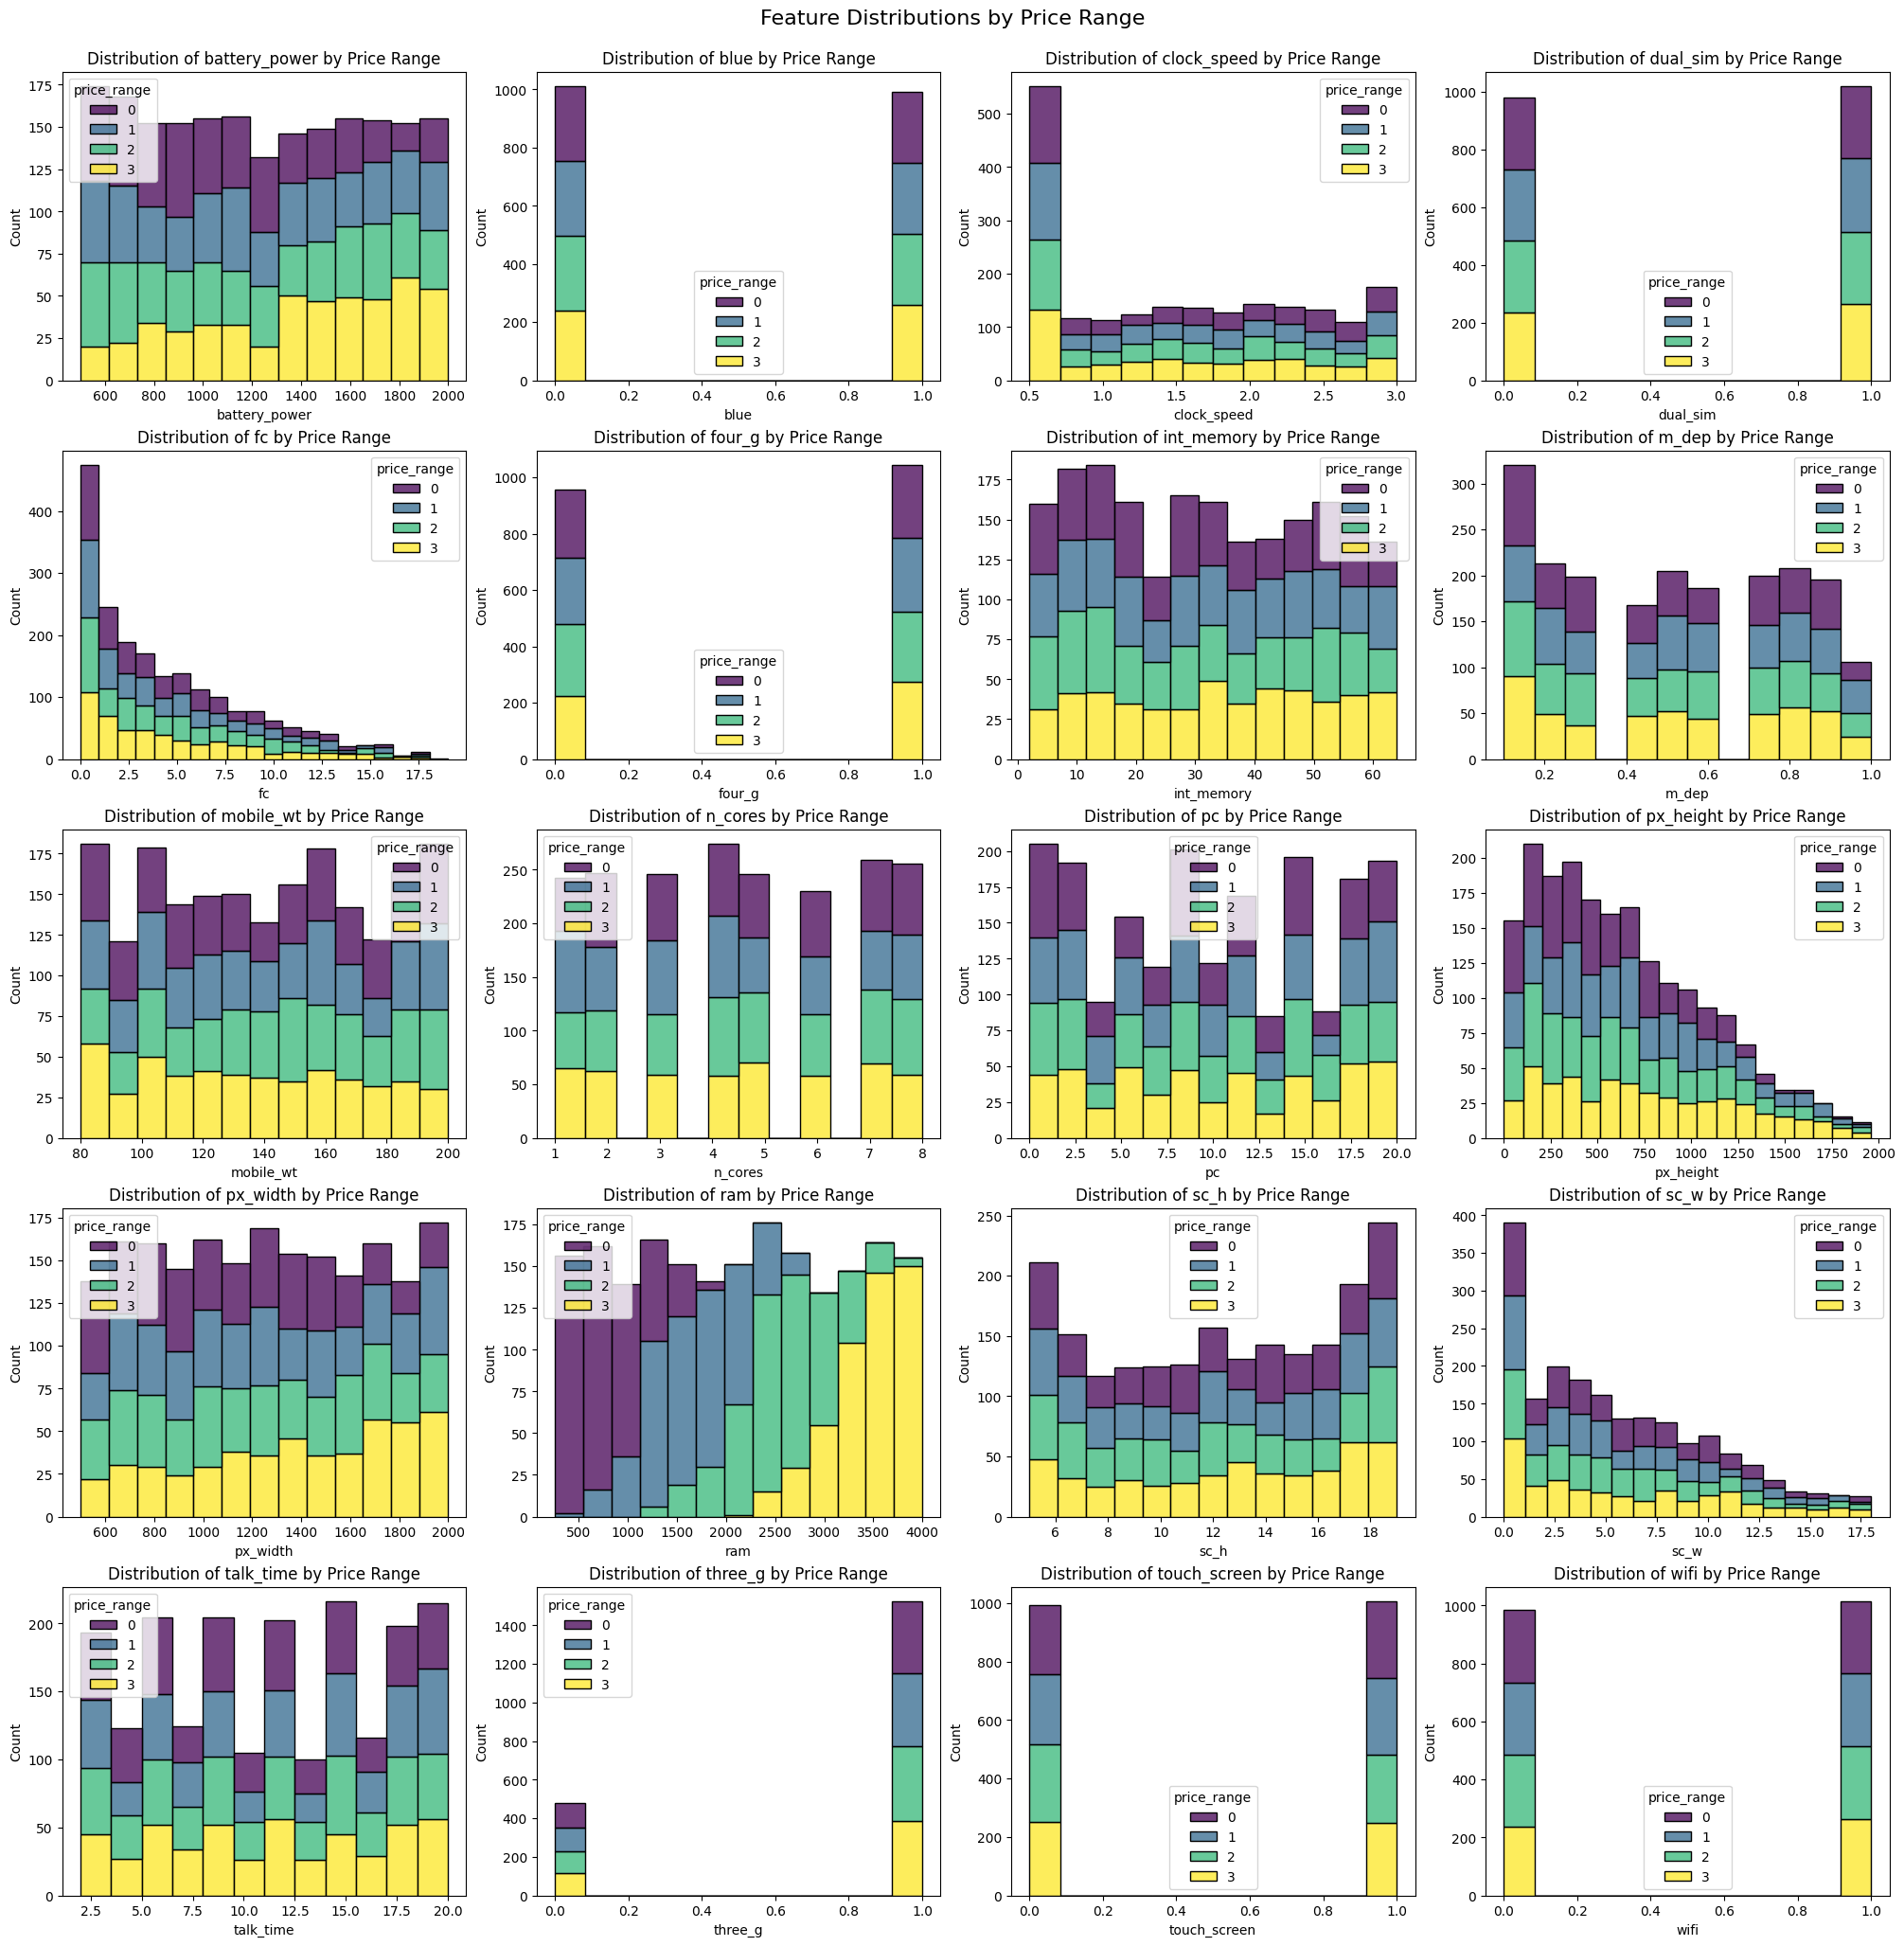

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

features = [col for col in df.columns if  col!= 'price_range']
n_features = len(features)

n_cols = 4
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_rows*4, n_cols*5), constrained_layout = True)
axes = axes.flatten()

for i, feature in enumerate(features):
  sns.histplot(data = df, x=feature, ax = axes[i], hue = 'price_range', palette = 'viridis', multiple = 'stack')
  axes[i].set_title(f'Distribution of {feature} by Price Range')
  axes[i].set_xlabel(feature)
  axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
  fig.delaxes(axes[j])

plt.suptitle('Feature Distributions by Price Range', y=1.02, fontsize=16)
plt.show()


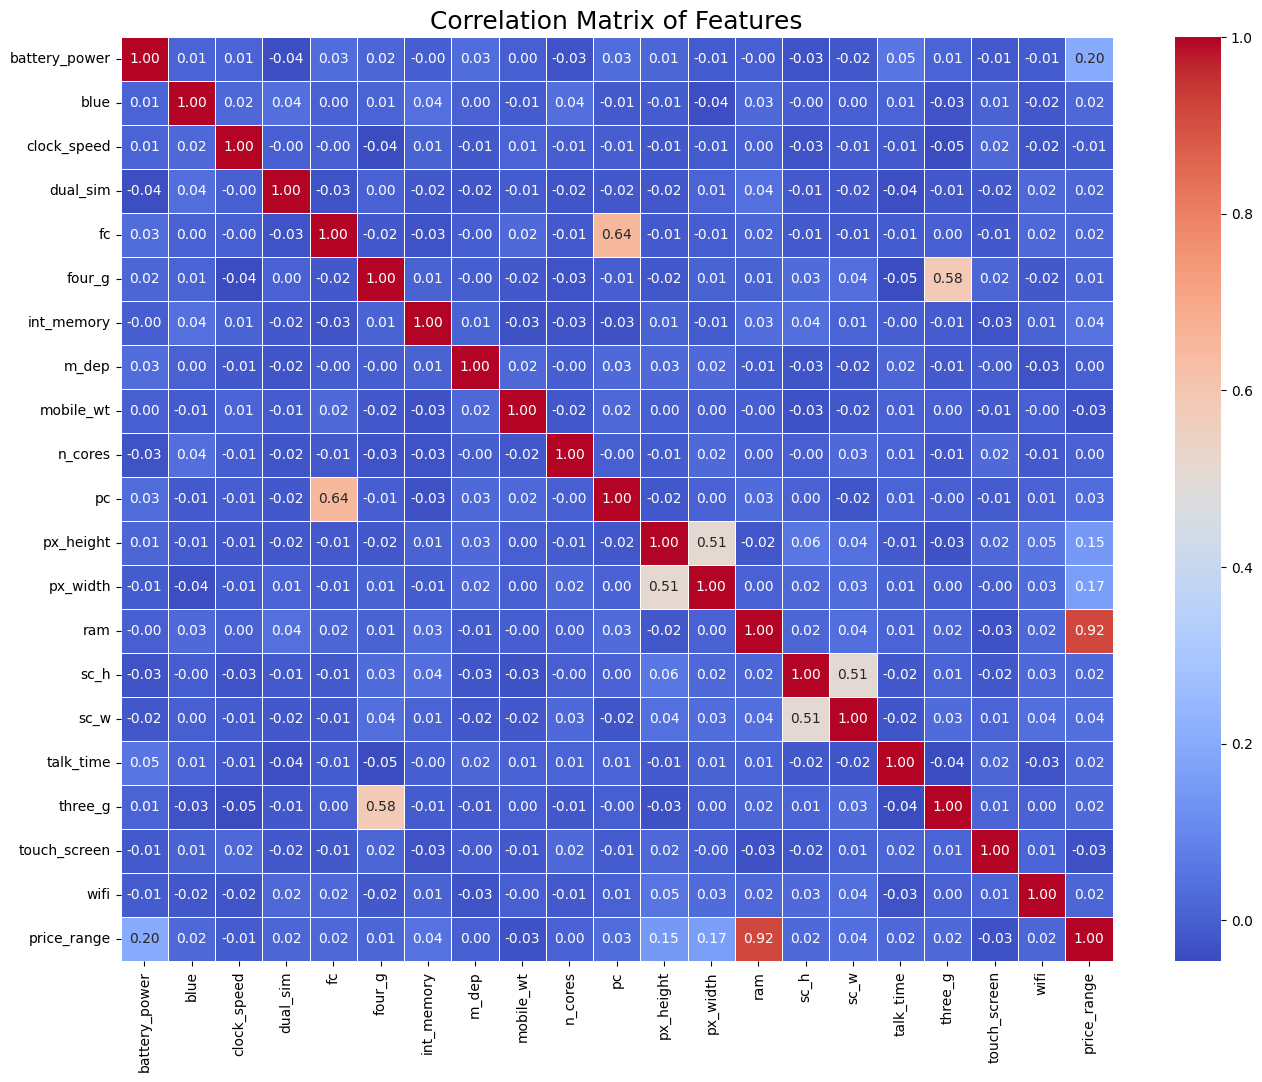

In [ ]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Features', fontsize=18)
plt.show()

In [ ]:
from sklearn.ensemble import IsolationForest
import numpy as np

iso_forest = IsolationForest(random_state=42, contamination=0.01)

features_for_outliers = df.drop(columns=['price_range']).columns
iso_forest.fit(df[features_for_outliers])

df['outlier_prediction'] = iso_forest.predict(df[features_for_outliers])

# Get the anomaly scores (lower score indicates higher anomaly likelihood)
df['anomaly_score'] = iso_forest.decision_function(df[features_for_outliers])

print("Number of outliers detected:", df[df['outlier_prediction'] == -1].shape[0])
print("\nFirst 5 rows with anomaly scores and predictions:")
display(df[['anomaly_score', 'outlier_prediction']].head())

Number of outliers detected: 20

First 5 rows with anomaly scores and predictions:


,anomaly_score,outlier_prediction
0,0.024826,1
1,0.063212,1
2,0.078978,1
3,0.076374,1
4,0.065057,1


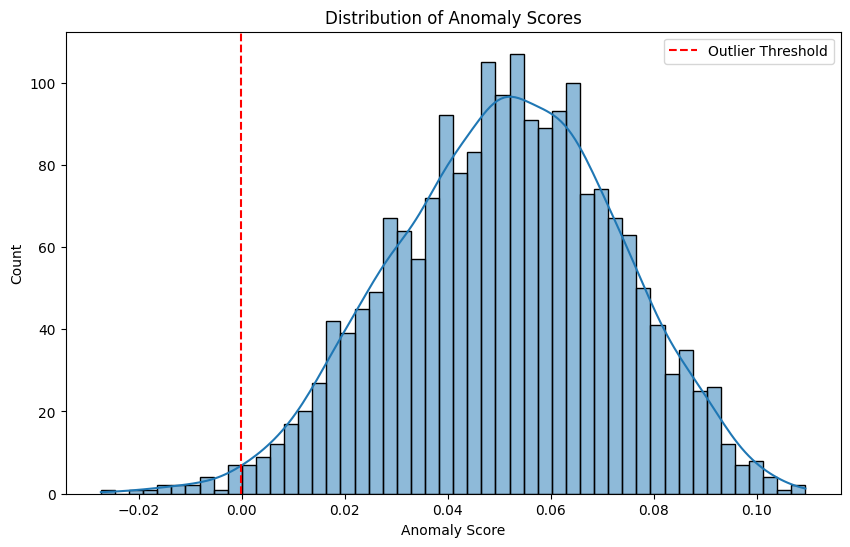

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['anomaly_score'], bins=50, kde=True)
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Count')
plt.axvline(x=df[df['outlier_prediction'] == -1]['anomaly_score'].max(), color='r', linestyle='--', label='Outlier Threshold')
plt.legend()
plt.show()

Now we develop and compare machine learning models (Random Forest, SVM, and XGBoost) to predict the 'price_range' of mobile phones, including data preparation, feature scaling, model training, and performance evaluation, culminating in a comparative analysis to identify the most effective model.

## Prepare Data for Modeling


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) and target (y)
X = df.drop(columns=['price_range', 'outlier_prediction', 'anomaly_score'])
y = df['price_range']

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# 3. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame for easier inspection
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\nFirst 5 rows of scaled training features:")
display(X_train_scaled.head())
print("\nFirst 5 rows of scaled testing features:")
display(X_test_scaled.head())

X_train shape: (1600, 20)
X_test shape: (400, 20)
y_train shape: (1600,)
y_test shape: (400,)

First 5 rows of scaled training features:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
968,1.548360,-0.981423,-1.236230,0.970437,0.620111,-1.046060,0.754832,-0.008935,1.425710,-1.547446,0.020269,0.275712,1.181997,-0.580476,-0.528061,0.759509,-1.445123,0.557137,0.990050,1.002503
240,-1.379535,1.018929,0.837112,-1.030464,-0.993561,0.955968,0.919763,-1.403674,-0.046246,1.510316,-1.476497,-0.258762,-0.556547,1.336453,-0.290196,-1.084869,0.915929,0.557137,0.990050,1.002503
819,-0.010914,-0.981423,-0.748385,0.970437,-0.532512,0.955968,1.359577,-1.403674,1.340790,-1.547446,0.685498,-0.285711,-1.020159,-0.657302,0.423400,1.451150,1.642407,0.557137,-1.010051,1.002503
692,-1.043621,-0.981423,-0.504462,-1.030464,-0.532512,-1.046060,0.315017,-0.357620,1.623858,0.199847,-0.478653,-0.764042,0.984962,1.288322,0.185535,0.528962,-1.081884,-1.794892,-1.010051,1.002503
420,0.488416,1.018929,-1.236230,0.970437,0.620111,-1.046060,-1.389265,-0.357620,-1.008680,0.199847,0.352883,0.401470,-0.336332,-0.489767,-1.479523,-0.162680,1.642407,0.557137,-1.010051,1.002503



First 5 rows of scaled testing features:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
1860,0.919657,-0.981423,1.202995,-1.030464,-0.301987,0.955968,-0.399682,0.339750,1.680472,-1.110623,-0.811268,-0.972891,0.831970,-1.323738,-1.003792,0.067867,0.007832,0.557137,0.990050,-0.997503
353,-0.133477,-0.981423,-1.236230,-1.030464,0.620111,0.955968,-1.334288,-0.008935,-0.074553,1.510316,1.018112,-0.829167,-0.609863,0.413624,1.612728,2.603886,1.460787,0.557137,-1.010051,-0.997503
1333,1.659574,-0.981423,1.690840,-1.030464,1.081160,-1.046060,-1.004427,-0.357620,1.567245,1.073493,1.350727,-0.788745,-0.688677,-0.740606,-1.003792,-1.084869,-0.537026,0.557137,0.990050,-0.997503
905,-0.571527,1.018929,0.593189,-1.030464,-0.071463,-1.046060,-0.839496,-1.054989,0.718039,-0.673800,1.517034,-0.871835,0.335906,1.643754,1.374862,0.298414,1.460787,0.557137,0.990050,-0.997503
1289,-1.420389,1.018929,-1.236230,0.970437,0.620111,-1.046060,1.414554,-0.008935,-0.301008,0.199847,-0.312346,0.846117,1.643291,-0.194499,0.423400,-0.162680,-1.081884,0.557137,-1.010051,-0.997503


## Train and Evaluate Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Instantiate a RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# 2. Train the Random Forest model
rf_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the X_test_scaled data
y_pred_rf = rf_model.predict(X_test_scaled)

# 4. Calculate and print the accuracy_score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

# 5. Generate and print a classification_report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# 6. Generate and print the confusion_matrix
print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8925

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       105
           1       0.89      0.87      0.88        91
           2       0.78      0.87      0.82        92
           3       0.94      0.87      0.90       112

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.90      0.89      0.89       400


Random Forest Confusion Matrix:
[[101   4   0   0]
 [  5  79   7   0]
 [  0   6  80   6]
 [  0   0  15  97]]


## Train and Evaluate Support Vector Machine (SVM) Classifier



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Instantiate an SVC model
svm_model = SVC(random_state=42)

# 2. Train the SVM model
svm_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the X_test_scaled data
y_pred_svm = svm_model.predict(X_test_scaled)

# 4. Calculate and print the accuracy_score
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Support Vector Classifier Accuracy: {accuracy_svm:.4f}")

# 5. Generate and print a classification_report
print("\nSupport Vector Classifier Classification Report:")
print(classification_report(y_test, y_pred_svm))

# 6. Generate and print the confusion_matrix
print("\nSupport Vector Classifier Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Support Vector Classifier Accuracy: 0.8925

Support Vector Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       105
           1       0.80      0.89      0.84        91
           2       0.84      0.82      0.83        92
           3       0.96      0.92      0.94       112

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.90      0.89      0.89       400


Support Vector Classifier Confusion Matrix:
[[ 98   7   0   0]
 [  5  81   5   0]
 [  0  13  75   4]
 [  0   0   9 103]]


## Train and Evaluate XGBoost Classifier





In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Instantiate an XGBoost Classifier model
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=4, random_state=42)

# 2. Train the XGBoost model
xgb_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the X_test_scaled data
y_pred_xgb = xgb_model.predict(X_test_scaled)

# 4. Calculate and print the accuracy_score
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Classifier Accuracy: {accuracy_xgb:.4f}")

# 5. Generate and print a classification_report
print("\nXGBoost Classifier Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# 6. Generate and print the confusion_matrix
print("\nXGBoost Classifier Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Classifier Accuracy: 0.9050

XGBoost Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       105
           1       0.87      0.95      0.91        91
           2       0.83      0.85      0.84        92
           3       0.94      0.88      0.91       112

    accuracy                           0.91       400
   macro avg       0.90      0.91      0.90       400
weighted avg       0.91      0.91      0.91       400


XGBoost Classifier Confusion Matrix:
[[100   5   0   0]
 [  3  86   2   0]
 [  0   8  78   6]
 [  0   0  14  98]]


## Compare Model Performances



In [ ]:
import pandas as pd

# Create a dictionary to store the accuracy scores
model_accuracies = {
    'Random Forest': accuracy_rf,
    'Support Vector Machine': accuracy_svm,
    'XGBoost': accuracy_xgb
}

# Convert the dictionary to a pandas Series for easy comparison
accuracy_series = pd.Series(model_accuracies)

print("Model Accuracy Comparison:")
print(accuracy_series)


Model Accuracy Comparison:
Random Forest             0.8925
Support Vector Machine    0.8925
XGBoost                   0.9050
dtype: float64


## Detailed Summary of Findings

### Data Overview and Preprocessing:

*   The `dataset.csv` file was loaded, containing **2000 entries** and **21 columns** related to mobile phone features and price range.
*   Initial checks using `df.info()` confirmed **no missing values** across all columns.
*   Data types primarily consisted of **19 integer columns** and **2 float64 columns**.
*   The target variable, `price_range`, is a categorical variable with 4 classes (0-3).
*   **Outlier detection** was performed using an **Isolation Forest** model, identifying 20 outliers. Anomaly scores were also calculated and visualized.
*   For modeling, features (`X`) were separated from the target (`y = price_range`). Columns `outlier_prediction` and `anomaly_score` were excluded from features.
*   The data was split into **training (80%) and testing (20%) sets** using `train_test_split` (1600 training, 400 testing samples).
*   Features were **scaled using `StandardScaler`** to standardize their range, which is crucial for models like SVM.

### Exploratory Data Analysis (EDA):

*   `df.head()` provided a quick glance at the data, while `df.describe()` offered statistical summaries of numerical features.
*   **Histograms of each feature by `price_range`** were plotted to visualize their distributions and how they vary across different price categories.
*   A **correlation matrix heatmap** was generated, revealing relationships between all features. Notable correlations include `ram` with `price_range`.
*   The distribution of **anomaly scores** from the Isolation Forest was visualized to show the separation between inliers and detected outliers.

### Machine Learning Model Performance:

Three classification models were trained and evaluated to predict `price_range`:

1.  **Random Forest Classifier:**
    *   **Accuracy Score:** 0.8925 (89.25%)
    *   **Classification Report:** Showed strong performance across classes, with precision, recall, and f1-scores generally above 0.80 for most classes.
    *   **Confusion Matrix:** `[[101   4   0   0], [  5  79   7   0], [  0   6  80   6], [  0   0  15  97]]` indicating good separation, with most misclassifications occurring between adjacent price ranges.

2.  **Support Vector Machine (SVC):**
    *   **Accuracy Score:** 0.8925 (89.25%)
    *   **Classification Report:** Similar to Random Forest, exhibiting high precision and recall, especially for classes 0 and 3.
    *   **Confusion Matrix:** `[[ 98   7   0   0], [  5  81   5   0], [  0  13  75   4], [  0   0   9 103]]` also demonstrating effective classification with some confusion between classes.

3.  **XGBoost Classifier:**
    *   **Accuracy Score:** **0.9050** (90.50%) - **Highest Accuracy**
    *   **Classification Report:** Generally showed slightly better precision, recall, and f1-scores compared to the other models, notably a higher recall for class 1 (0.95).
    *   **Confusion Matrix:** `[[100   5   0   0], [  3  86   2   0], [  0   8  78   6], [  0   0  14  98]]` with fewer overall misclassifications, particularly for diagonal elements, indicating better class separation.

### Conclusion:

Based on the comparative analysis, the **XGBoost Classifier** emerged as the **most effective model** for predicting the mobile phone price range in this scenario, achieving the highest overall accuracy of 0.9050. It also demonstrated robust performance across other metrics (precision, recall, f1-score) and showed slightly fewer misclassifications in its confusion matrix compared to the Random Forest and Support Vector Machine models, which both achieved an accuracy of 0.8925.